In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
import warnings
warnings.filterwarnings("ignore")

In [81]:
path = kagglehub.dataset_download("shivasingh4945/student-social-media-and-mental-health-impact")

df = pd.read_csv(os.path.join(path, "Student Social Media And Mental Health Impact.csv"))
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [83]:
df.shape

(5000, 13)

In [84]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [85]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [86]:
df.duplicated().sum()

np.int64(2)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

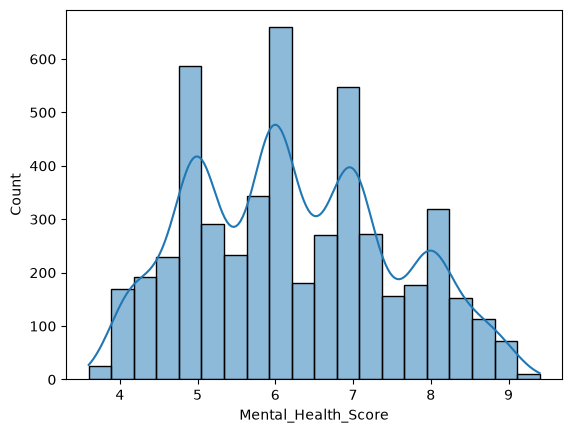

In [87]:
sns.histplot(df['Mental_Health_Score'], bins=20, kde=True)

<Axes: >

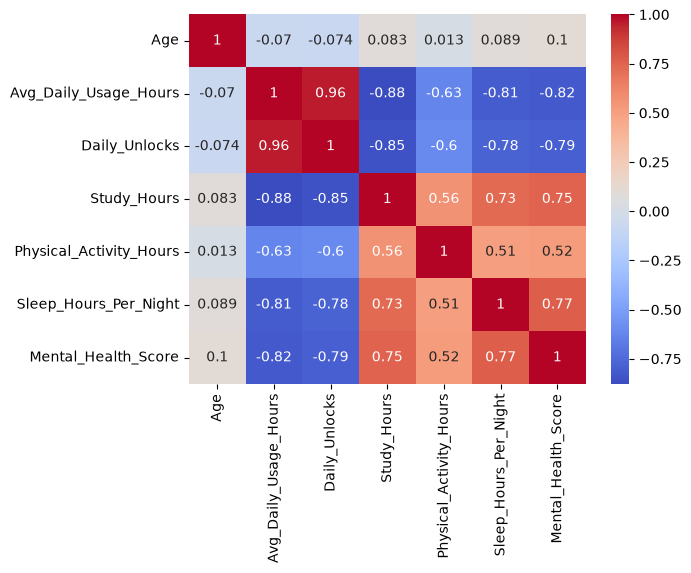

In [88]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [89]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

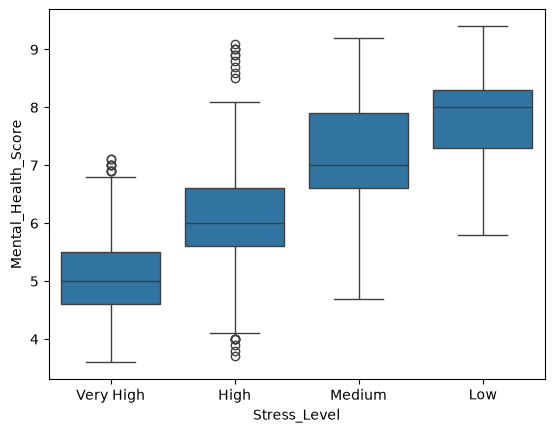

In [90]:
order = df['Stress_Level'].value_counts().index
sns.boxplot(x='Stress_Level',y ='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Country', ylabel='Mental_Health_Score'>

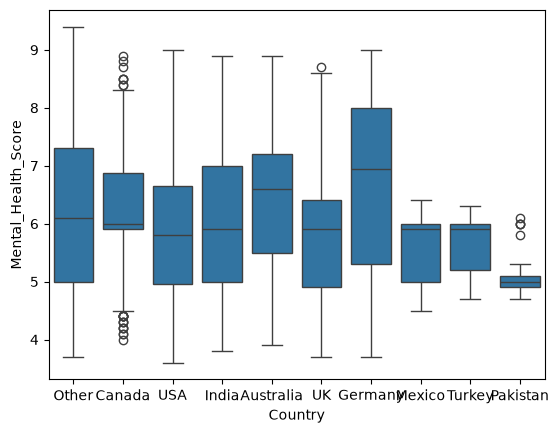

In [91]:
# Get the top 9 countries and manually add Pakistan
top_countries = df['Country'].value_counts().nlargest(9).index

if 'Pakistan' not in top_countries:
    top_countries = top_countries.insert(0, 'Pakistan') # Adds to the front
else:
    # If already in top 9, just grab the full top 10
    top_countries = df['Country'].value_counts().nlargest(10).index
    
sns.boxplot(x='Country', y='Mental_Health_Score', data=df[df['Country'].isin(top_countries)])

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

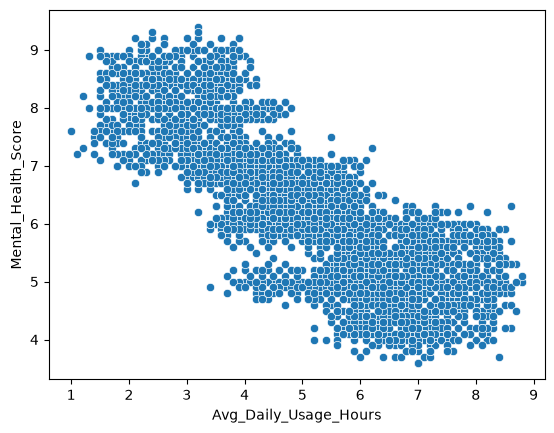

In [92]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)

In [93]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = ((df[numeric_features] < lower_bound) | (df[numeric_features] > upper_bound)).sum()
print("Number of outliers in each numeric feature:\n", outliers)

Number of outliers in each numeric feature:
 Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [94]:
df = df.drop_duplicates()

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [95]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [96]:
numeric_features = df.select_dtypes(include=[np.number])
numeric_features.skew().sort_values(ascending=False)


Study_Hours                0.436125
Mental_Health_Score        0.207086
Age                        0.155008
Sleep_Hours_Per_Night      0.123919
Physical_Activity_Hours    0.053288
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
dtype: float64

In [97]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'
    
df['Country_Grouped'] = df['Country'].apply(group_countries)

In [98]:
df['Country_Grouped'].value_counts()

Country_Grouped
Other        3265
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
Pakistan       53
Name: count, dtype: int64

In [99]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Country_Grouped
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [100]:
from sklearn.model_selection import train_test_split

skewed_col = ['Study_Hours']
numeric_col = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours", "Sleep_Hours_Per_Night"]

ordinal_col = ["Stress_Level"]
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Country_Grouped"]

features = numeric_col + ordinal_col + normal_col + skewed_col

X = df[features]
y = df['Mental_Health_Score']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [101]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Skewed columns
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

#numeric columns
numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#ordinal columns
ordinal_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High','Very High']]))
])

#normal columns
normal_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('skew', skew_pipeline, skewed_col),
    ('num', numeric_pipeline, numeric_col),
    ('ord', ordinal_pipeline, ordinal_col),
    ('norm', normal_pipeline, normal_col)
])

preprocessor



,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [102]:
# BaseModel Pipeline (Linear Regression)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(x_train, y_train)
y_pred_test = lr_pipeline.predict(x_test)
y_pred_train = lr_pipeline.predict(x_train)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# RMSE (root mean squared error)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# MAE (mean absolute error)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Train R2: {train_r2:.4f}, Test R2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")

Train R2: 0.7368, Test R2: 0.7520
Train RMSE: 0.6450, Test RMSE: 0.6600
Train MAE: 0.5082, Test MAE: 0.5232


In [103]:
#Random Forest Regressor (Default)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))   
])

rf_pipeline.fit(x_train, y_train)
y_pred_test_rf = rf_pipeline.predict(x_test)
y_pred_train_rf = rf_pipeline.predict(x_train)

train_r2_rf = r2_score(y_train, y_pred_train_rf)
test_r2_rf = r2_score(y_test, y_pred_test_rf)

train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

train_mae_rf = mean_absolute_error(y_train, y_pred_train_rf)
test_mae_rf = mean_absolute_error(y_test, y_pred_test_rf)

print(f"Random Forest - Train R2: {train_r2_rf:.4f}, Test R2: {test_r2_rf:.4f}")
print(f"Random Forest - Train RMSE: {train_rmse_rf:.4f}, Test RMSE: {test_rmse_rf:.4f}")
print(f"Random Forest - Train MAE: {train_mae_rf:.4f}, Test MAE: {test_mae_rf:.4f}")

Random Forest - Train R2: 0.9820, Test R2: 0.8778
Random Forest - Train RMSE: 0.1687, Test RMSE: 0.4633
Random Forest - Train MAE: 0.1238, Test MAE: 0.3441


In [104]:
# Hyperparameter Tuning for Random Forest Regressor
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'regressor__n_estimators': [100, 200, 300, 400, 500],
    'regressor__max_depth': [None, 10, 20, 30, 40, 50],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(rf_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [None, 10, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this`

In [105]:
best_pipeline = search.best_estimator_
y_pred_test_best = best_pipeline.predict(x_test)
y_pred_train_best = best_pipeline.predict(x_train)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_pipeline_train_r2 = r2_score(y_train, y_pred_train_best)
best_pipeline_test_r2 = r2_score(y_test, y_pred_test_best)

best_pipeline_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_best))
best_pipeline_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_best))
best_pipeline_train_mae = mean_absolute_error(y_train, y_pred_train_best)
best_pipeline_test_mae = mean_absolute_error(y_test, y_pred_test_best)

print(f"Best Pipeline - Train R2: {best_pipeline_train_r2:.4f}, Test R2: {best_pipeline_test_r2:.4f}")
print(f"Best Pipeline - Train RMSE: {best_pipeline_train_rmse:.4f}, Test RMSE: {best_pipeline_test_rmse:.4f}")
print(f"Best Pipeline - Train MAE: {best_pipeline_train_mae:.4f}, Test MAE: {best_pipeline_test_mae:.4f}")

Best Pipeline - Train R2: 0.9828, Test R2: 0.8788
Best Pipeline - Train RMSE: 0.1650, Test RMSE: 0.4613
Best Pipeline - Train MAE: 0.1220, Test MAE: 0.3430


In [106]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
lr_mae = mean_absolute_error(y_test, y_pred_test)

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
rf_mae = mean_absolute_error(y_test, y_pred_test_rf)

# Calculate RMSE and MAE for tuned Random Forest
rf_tuned_preds          = search.best_estimator_.predict(x_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = search.best_estimator_.predict(x_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)

# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [test_r2, test_r2_rf, rf_tuned_r2],
    'Training R2': [train_r2, train_r2_rf, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.751994     0.736831  0.523160  0.659994
1  Random Forest (default)  0.877777     0.982003  0.344081  0.463324
2    Random Forest (tuned)  0.878841     0.982777  0.342984  0.461303


In [107]:
import joblib

joblib.dump(best_pipeline, 'mental_health_model.pkl')
print("Model saved as 'mental_health_model.pkl'")

Model saved as 'mental_health_model.pkl'
